Training samples: 398
Test samples: 171


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



No Regularization:
AUC-ROC: 0.995

L1 (Lasso):
AUC-ROC: 0.998

L2 (Ridge):
AUC-ROC: 0.997

Cross-Validation Scores: [0.9625     0.925      0.9625     0.96202532 0.89873418]
Mean CV Score: 0.942


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


ROC curve saved!

Classification Report (L2):
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



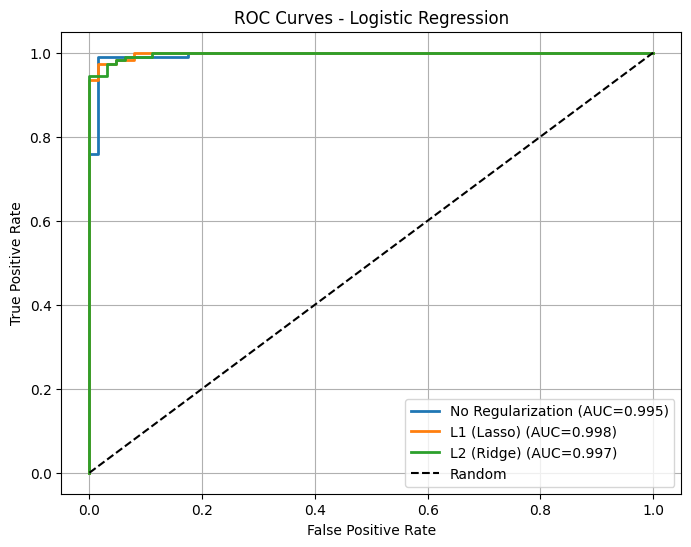

In [1]:
"""
Assignment 5: Logistic Regression
ROC Curve and Regularization
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training samples:", len(y_train))
print("Test samples:", len(y_test))

# Train models with different regularization
models = {
    'No Regularization': LogisticRegression(penalty=None, max_iter=5000),
    'L1 (Lasso)': LogisticRegression(penalty='l1', solver='liblinear'),
    'L2 (Ridge)': LogisticRegression(penalty='l2')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'probs': y_prob, 'auc': auc}
    print(f"\n{name}:")
    print(f"AUC-ROC: {auc:.3f}")

# Cross-validation
cv_scores = cross_val_score(models['L2 (Ridge)'], X_train, y_train, cv=5)
print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.3f}")

# Plot ROC Curves
plt.figure(figsize=(8, 6))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['probs'])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={result['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Logistic Regression')
plt.legend()
plt.grid(True)
plt.savefig('assignment5_roc.png')
print("\nROC curve saved!")

# Classification report for best model
y_pred = models['L2 (Ridge)'].predict(X_test)
print("\nClassification Report (L2):")
print(classification_report(y_test, y_pred))